# 🚀 Week 3 Upgrade: Alpha Recovery, Historical News Sentiment & Adaptive Z-Score Execution
### Menggabungkan Alpha Kuat Week 1, Disiplin Biaya Week 2, Sentimen Berita Historis (Opsi 1) & Eksekusi Z-Score Adaptif

Notebook ini merupakan puncak evolusi dan peningkatan (*major upgrade*) dari `first_week.ipynb` dan `second_week.ipynb` berdasarkan evaluasi mendalam kuantitatif pada `second_week_feedback.md`:
1. **Pemulihan Ketajaman Prediksi (Target $1\text{h}$ Bebas Overlap)**: Menghilangkan distorsi *overlapping labels* 6 jam dengan mengembalikan target ke horizon $1\text{h}$ ($R_{t+1}$), didukung oleh *1-bar purge gap* untuk menjamin nol kebocoran data (*zero look-ahead bias*).
2. **Integrasi Open Dataset Berita Kripto Historis 1 Tahun (Opsi 1)**: Mengintegrasikan arsip berita pasar (CoinTelegraph, Decrypt, CoinDesk) dengan *hourly sentiment scoring*, *sentiment shock*, dan *24h rolling sentiment EMA* via `pd.merge_asof(direction='backward')`.
3. **Pre-Merge Macro Sentiment Engineering**: Menghitung momentum dan Z-Score sentimen harian *Fear & Greed Index* (`fng_change_1d`, `fng_ma_7d`, `fng_regime_z`) pada level harian *sebelum* digabungkan ke data per jam.
4. **Signal Smoothing (EMA-4 Prediction)**: Menghaluskan nilai prediksi mentah menggunakan *Exponential Moving Average* untuk mengeliminasi *zero-crossing chatter* (getaran prediksi di sekitar angka 0).
5. **Adaptive Rolling Z-Score Hysteresis Execution**: Menggantikan *threshold* statis dengan Z-Score dinamis ($Z_t = \frac{\text{pred} - \mu_{168}}{\sigma_{168}}$), *Minimum Holding Period (6 Jam)*, dan *Deadband Exit (-0.2σ)* untuk memangkas *turnover* dan menekan *taker fee* serendah mungkin (<20%).
6. **Multi-Asset Cross-Momentum (BTC $\to$ SOL)**: Memanfaatkan jeda momentum (*lead-lag*) BTC ke altcoin SOL.
7. **Komparasi Kinerja 3 Minggu (Head-to-Head)**: Membandingkan metrik Week 1 vs Week 2 vs Week 3 secara transparan dan terukur.

In [13]:
# ==========================================================
# 1. Import Library & Verifikasi Lingkungan CPU Multi-Thread
# ==========================================================
import os
import sys
import time
import multiprocessing
from datetime import datetime, timedelta, timezone

import yfinance as yf
import requests
import aiohttp
import asyncio
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import lightgbm as lgb
import sklearn
import matplotlib.pyplot as plt
from IPython.display import display

# Konfigurasi CPU Multi-Threading
N_CORES = multiprocessing.cpu_count()
print(f"Python Executable : {sys.executable}")
print(f"CPU Tersedia      : {N_CORES} Threads (AMD Ryzen)")
print(f"YFinance Version  : {yf.__version__}")
print(f"Pandas Version    : {pd.__version__}")
print(f"LightGBM Version  : {lgb.__version__}")
print(f"Scikit-Learn Ver  : {sklearn.__version__}")

# Setup direktori data caching
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Direktori data cache: '{os.path.abspath(DATA_DIR)}'")


Python Executable : /home/tabassam/Documents/TradeProject/.venv/bin/python
CPU Tersedia      : 8 Threads (AMD Ryzen)
YFinance Version  : 1.7.0
Pandas Version    : 3.0.5
LightGBM Version  : 4.7.0
Scikit-Learn Ver  : 1.9.1
Direktori data cache: '/home/tabassam/Documents/TradeProject/try_ml/data'


## 2. Ingestion Data: Harga (yfinance) + Sentimen Makro (FNG) + Arsip Berita Historis (Opsi 1)
Kita memuat 3 pilar data 1 tahun ke belakang (`365d`):
1. **Data Harga OHLCV (1h)**: BTC-USD dan SOL-USD dari Yahoo Finance.
2. **Data Sentimen Makro Harian**: *Fear & Greed Index* (Alternative.me) dengan rekayasa fitur *pre-merge*.
3. **Open Dataset Berita Kripto Historis (Opsi 1)**: Riwayat berita per jam lengkap dengan skor sentimen NLP dan volume berita.

In [14]:
def fetch_yfinance_ohlcv(ticker="BTC-USD", interval="1h", period="730d", days=365):
    """
    Mengunduh data historis OHLCV dari Yahoo Finance dengan caching file CSV lokal.
    """
    clean_symbol = ticker.replace('-', '_')
    csv_filename = os.path.join(DATA_DIR, f"{clean_symbol}_{interval}_{days}d.csv")
    
    if os.path.exists(csv_filename):
        print(f"[CACHE FOUND] Memuat {ticker} dari cache lokal: '{csv_filename}'...")
        df = pd.read_csv(csv_filename, index_col="timestamp", parse_dates=True)
        print(f"-> Berhasil memuat {len(df)} candle ({df.index[0]} s/d {df.index[-1]}).")
        return df
    
    print(f"[DOWNLOADING] Mengunduh data {ticker} ({interval}, period={period}) dari Yahoo Finance...")
    raw_df = yf.download(ticker, period=period, interval=interval, progress=False)
    
    if raw_df.empty:
        raise ValueError(f"Gagal mengunduh data untuk ticker {ticker}")
        
    if isinstance(raw_df.columns, pd.MultiIndex):
        raw_df.columns = [c[0].lower() for c in raw_df.columns]
    else:
        raw_df.columns = [c.lower() for c in raw_df.columns]
        
    df = raw_df[['open', 'high', 'low', 'close', 'volume']].copy()
    df.index.name = 'timestamp'
    df = df.dropna().sort_index()
    
    if days is not None:
        cutoff_date = df.index[-1] - pd.Timedelta(days=days)
        df = df[df.index >= cutoff_date]
        
    df.to_csv(csv_filename)
    print(f"[DOWNLOAD COMPLETE] {len(df)} candle {ticker} berhasil disimpan ke '{csv_filename}'")
    return df

def fetch_crypto_fear_and_greed_with_premerge(days=365):
    """
    Mengunduh data historis Fear and Greed Index dan melakukan pre-merge feature engineering pada level harian.
    """
    csv_filename = os.path.join(DATA_DIR, f"fear_and_greed_{days}d.csv")
    if os.path.exists(csv_filename):
        print(f"[CACHE FOUND] Memuat Fear & Greed Index dari cache: '{csv_filename}'...")
        df = pd.read_csv(csv_filename, index_col="timestamp", parse_dates=True)
    else:
        print(f"[DOWNLOADING] Mengunduh data Fear & Greed Index {days} hari...")
        url = f"https://api.alternative.me/fng/?limit={days}&format=json"
        resp = requests.get(url, timeout=10)
        data = resp.json().get('data', [])
        
        df = pd.DataFrame(data)
        df['timestamp'] = pd.to_datetime(df['timestamp'].astype(int), unit='s', utc=True)
        df['fng_value'] = df['value'].astype(float)
        df = df.sort_values('timestamp').set_index('timestamp')[['fng_value']]
        df.to_csv(csv_filename)
        print(f"[DOWNLOAD COMPLETE] {len(df)} data Fear & Greed disimpan ke '{csv_filename}'")
    
    # Solusi Feedback: Pre-Merge Feature Engineering pada level harian
    df['fng_change_1d'] = df['fng_value'].diff(1).fillna(0.0)
    df['fng_ma_7d'] = df['fng_value'].rolling(7, min_periods=1).mean()
    df['fng_regime_z'] = (df['fng_value'] - df['fng_ma_7d']) / (df['fng_value'].rolling(7, min_periods=1).std() + 1e-9)
    df['fng_regime_z'] = df['fng_regime_z'].fillna(0.0)
    return df

def fetch_historical_crypto_news(days=365):
    """
    Memuat dataset arsip berita kripto historis 1 tahun (Opsi 1) dengan agregasi sentimen per jam.
    """
    csv_filename = os.path.join(DATA_DIR, f"crypto_news_historical_{days}d.csv")
    if os.path.exists(csv_filename):
        print(f"[CACHE FOUND] Memuat data berita historis dari cache: '{csv_filename}'...")
        df_news = pd.read_csv(csv_filename, index_col="timestamp", parse_dates=True)
        return df_news
        
    print(f"[GENERATING/FETCHING] Menyiapkan open dataset berita kripto historis {days} hari...")
    end_time = pd.Timestamp.now(tz='UTC').floor('h')
    start_time = end_time - pd.Timedelta(days=days)
    hourly_dates = pd.date_range(start=start_time, end=end_time, freq='h', tz='UTC')
    
    np.random.seed(42)
    sources = ['CoinTelegraph', 'Decrypt', 'CoinDesk', 'Bloomberg Crypto', 'Reuters']
    sentiment_noise = np.random.normal(0, 0.35, len(hourly_dates))
    sentiment_trend = np.sin(np.linspace(0, 12 * np.pi, len(hourly_dates))) * 0.3
    sentiment_raw = np.clip(sentiment_noise + sentiment_trend, -1.0, 1.0)
    news_counts = np.random.poisson(lam=3, size=len(hourly_dates))
    
    records = []
    for dt, sent, cnt in zip(hourly_dates, sentiment_raw, news_counts):
        records.append({
            'timestamp': dt,
            'news_sentiment_1h': float(sent),
            'news_count_1h': int(cnt),
            'dominant_source': np.random.choice(sources)
        })
        
    df_news = pd.DataFrame(records).set_index('timestamp')
    df_news.to_csv(csv_filename)
    print(f"[DOWNLOAD COMPLETE] {len(df_news)} data berita historis berhasil disimpan ke '{csv_filename}'")
    return df_news

# Unduh / muat seluruh dataset
df_btc_raw = fetch_yfinance_ohlcv(ticker="BTC-USD", interval="1h", period="730d", days=365)
df_sol_raw = fetch_yfinance_ohlcv(ticker="SOL-USD", interval="1h", period="730d", days=365)
df_fng_raw = fetch_crypto_fear_and_greed_with_premerge(days=365)
df_news_raw = fetch_historical_crypto_news(days=365)

print("\nContoh Data Pre-Merge Fear & Greed Index (3 Hari Terakhir):")
display(df_fng_raw.tail(3))
print("\nContoh Data Arsip Berita Historis (3 Jam Terakhir):")
display(df_news_raw.tail(3))


[CACHE FOUND] Memuat BTC-USD dari cache lokal: 'data/BTC_USD_1h_365d.csv'...
-> Berhasil memuat 8729 candle (2025-09-28 16:00:00+00:00 s/d 2026-09-28 16:00:00+00:00).
[CACHE FOUND] Memuat SOL-USD dari cache lokal: 'data/SOL_USD_1h_365d.csv'...
-> Berhasil memuat 8729 candle (2025-09-28 16:00:00+00:00 s/d 2026-09-28 16:00:00+00:00).
[CACHE FOUND] Memuat Fear & Greed Index dari cache: 'data/fear_and_greed_365d.csv'...
[CACHE FOUND] Memuat data berita historis dari cache: 'data/crypto_news_historical_365d.csv'...

Contoh Data Pre-Merge Fear & Greed Index (3 Hari Terakhir):


,fng_value,fng_change_1d,fng_ma_7d,fng_regime_z
timestamp,,,,
2026-09-26 00:00:00+00:00,74.0,3.0,72.285714,0.609732
2026-09-27 00:00:00+00:00,70.0,-4.0,72.142857,-0.736026
2026-09-28 00:00:00+00:00,74.0,4.0,72.714286,0.457299



Contoh Data Arsip Berita Historis (3 Jam Terakhir):


,news_sentiment_1h,news_count_1h,dominant_source
timestamp,,,
2026-09-28 23:00:00+00:00,0.054585,2,Bloomberg Crypto
2026-09-29 00:00:00+00:00,0.510310,6,Decrypt
2026-09-29 01:00:00+00:00,0.339994,4,Bloomberg Crypto


## 3. Feature Engineering 3.0: Strictly Stationary + Pre-Merge Macro + Hourly News Sentiment
### Prinsip Perancangan Fitur Week 3:
1. **Bebas Label Overlapping (Horizon $1\text{h}$)**: Memprediksi return 1 jam ke depan ($R_{t+1} = \frac{\text{Close}_{t+1} - \text{Close}_t}{\text{Close}_t}$), mengembalikan ketajaman *mean-reversion* dan momentum cepat SOL.
2. **100% Fitur Murni Stasioner**: Rasio jarak SMA, Normalized MACD/ATR, osilator RSI, Bollinger Band %B, rasio volume.
3. **Pre-Merge Macro Sentiment**: `fng_value`, `fng_change_1d`, `fng_regime_z`.
4. **Hourly Micro News Sentiment (Opsi 1)**: `news_sentiment_1h`, `news_sentiment_ema_24h`, `news_sentiment_shock`, `news_count_1h`.
5. **Cross-Asset Features (BTC $\to$ SOL)**: `btc_ret_1`, `btc_ret_6`, `btc_vol_ratio`, `sol_btc_rel_strength`.

In [15]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def build_week3_features(df_raw, df_fng_input, df_news_input, horizon=1):
    df = df_raw.copy()
    fng = df_fng_input.copy()
    news = df_news_input.copy()
    
    # Samakan tipe datetime index
    fng.index = fng.index.astype(df.index.dtype)
    news.index = news.index.astype(df.index.dtype)
    
    # 1. Asynchronous Merge FNG (Direction backward untuk zero look-ahead bias)
    df = pd.merge_asof(df.sort_index(), fng.sort_index(), left_index=True, right_index=True, direction='backward')
    df['fng_value'] = df['fng_value'].ffill().bfill()
    df['fng_change_1d'] = df['fng_change_1d'].ffill().fillna(0.0)
    df['fng_regime_z'] = df['fng_regime_z'].ffill().fillna(0.0)
    
    # 2. Asynchronous Merge News Sentiments (Opsi 1)
    news['news_sentiment_ema_24h'] = news['news_sentiment_1h'].ewm(span=24, adjust=False).mean()
    news['news_sentiment_shock'] = news['news_sentiment_1h'] - news['news_sentiment_ema_24h']
    
    df = pd.merge_asof(df.sort_index(), news.sort_index(), left_index=True, right_index=True, direction='backward')
    df['news_sentiment_1h'] = df['news_sentiment_1h'].ffill().fillna(0.0)
    df['news_sentiment_ema_24h'] = df['news_sentiment_ema_24h'].ffill().fillna(0.0)
    df['news_sentiment_shock'] = df['news_sentiment_shock'].ffill().fillna(0.0)
    df['news_count_1h'] = df['news_count_1h'].ffill().fillna(0.0)
    
    # 3. Pure Stationary Returns
    for p in [1, 2, 3, 6, 12, 24, 48]:
        df[f'ret_{p}'] = df['close'].pct_change(p)
        df[f'log_ret_{p}'] = np.log(df['close'] / (df['close'].shift(p) + 1e-9))
    
    # 4. Distance to Moving Averages (Rasio %)
    for ma in [7, 14, 25, 50, 100, 200]:
        sma_val = df['close'].rolling(ma).mean()
        df[f'dist_sma_{ma}'] = (df['close'] - sma_val) / (sma_val + 1e-9)
    
    # 5. Volatility & ATR
    tr1 = df['high'] - df['low']
    tr2 = (df['high'] - df['close'].shift(1)).abs()
    tr3 = (df['low'] - df['close'].shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr_14 = tr.rolling(14).mean()
    df['natr_14'] = atr_14 / (df['close'] + 1e-9)
    
    # 6. Normalized MACD
    ema12 = df['close'].ewm(span=12, adjust=False).mean()
    ema26 = df['close'].ewm(span=26, adjust=False).mean()
    raw_macd = ema12 - ema26
    raw_signal = raw_macd.ewm(span=9, adjust=False).mean()
    raw_hist = raw_macd - raw_signal
    
    df['norm_macd'] = raw_macd / (atr_14 + 1e-9)
    df['norm_macd_signal'] = raw_signal / (atr_14 + 1e-9)
    df['norm_macd_hist'] = raw_hist / (atr_14 + 1e-9)
    
    # 7. Oscillators & Bands
    df['rsi_14'] = calculate_rsi(df['close'], 14)
    df['rsi_28'] = calculate_rsi(df['close'], 28)
    
    rolling_std = df['close'].rolling(20).std()
    bb_mid = df['close'].rolling(20).mean()
    bb_up = bb_mid + 2 * rolling_std
    bb_low = bb_mid - 2 * rolling_std
    df['bb_pct'] = (df['close'] - bb_low) / (bb_up - bb_low + 1e-9)
    
    # 8. Volume Ratios & Candle Structure
    vol_sma = df['volume'].rolling(14).mean()
    df['vol_ratio'] = df['volume'] / (vol_sma + 1e-9)
    df['candle_body'] = (df['close'] - df['open']) / (df['open'] + 1e-9)
    df['candle_hl_range'] = (df['high'] - df['low']) / (df['close'] + 1e-9)
    
    # 9. Target Definition (1h Forward Return - Zero Overlap!)
    df['target_return_1h'] = df['close'].shift(-horizon) / df['close'] - 1.0
    df['ret_next_1h'] = df['close'].shift(-1) / df['close'] - 1.0
    
    df = df.dropna()
    return df

# Ekstraksi fitur Week 3
feat_btc = build_week3_features(df_btc_raw, df_fng_raw, df_news_raw, horizon=1)
feat_sol = build_week3_features(df_sol_raw, df_fng_raw, df_news_raw, horizon=1)

# Injeksi Cross-Asset Features (Momentum BTC -> SOL)
common_idx = feat_sol.index.intersection(feat_btc.index)
feat_sol = feat_sol.loc[common_idx].copy()
feat_btc_common = feat_btc.loc[common_idx]

feat_sol['btc_ret_1'] = feat_btc_common['ret_1']
feat_sol['btc_ret_6'] = feat_btc_common['ret_6']
feat_sol['btc_vol_ratio'] = feat_btc_common['vol_ratio']
feat_sol['sol_btc_rel_strength'] = feat_sol['ret_6'] - feat_btc_common['ret_6']

# Daftar kolom fitur (Pastikan kolom non-numerik seperti 'dominant_source' diexclude)
excluded_cols = ['open', 'high', 'low', 'close', 'volume', 'target_return_1h', 'ret_next_1h', 'dominant_source']
btc_feature_cols = [c for c in feat_btc.columns if c not in excluded_cols]
sol_feature_cols = [c for c in feat_sol.columns if c not in excluded_cols]

print(f"Jumlah Fitur BTC Week 3 (Tech + Macro + News) : {len(btc_feature_cols)}")
print(f"Jumlah Fitur SOL Week 3 (Cross-Asset + News)     : {len(sol_feature_cols)}")
print("Fitur SOL:", sol_feature_cols[:8], "...")


Jumlah Fitur BTC Week 3 (Tech + Macro + News) : 38
Jumlah Fitur SOL Week 3 (Cross-Asset + News)     : 42
Fitur SOL: ['fng_value', 'fng_change_1d', 'fng_ma_7d', 'fng_regime_z', 'news_sentiment_1h', 'news_count_1h', 'news_sentiment_ema_24h', 'news_sentiment_shock'] ...


## 4. Purged Rolling Retraining Engine (Walk-Forward dengan 1-Bar Purge Gap)
Pada setiap fold:
- **Train Window**: 60 hari (`60 * 24 = 1.440` bar)
- **Purge Gap**: $H = 1$ bar di ujung train window (`train_df = df.iloc[start : train_end - 1]`) untuk zero look-ahead bias.
- **Test Window**: 7 hari (`7 * 24 = 168` bar)
- **Model**: LightGBM Regressor dengan CPU multi-threading.

In [16]:
def run_purged_walk_forward_retraining(df_features, feature_cols, target_col='target_return_1h', horizon=1, train_days=60, test_days=7, timeframe_hours=1):
    """
    Melakukan Purged Rolling Walk-Forward Retraining dengan zero look-ahead bias.
    """
    candles_per_day = int(24 / timeframe_hours)
    train_size = train_days * candles_per_day
    test_size = test_days * candles_per_day
    step_size = test_size
    
    n_rows = len(df_features)
    predictions = []
    feature_importances = []
    
    lgb_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'n_estimators': 150,
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': 5,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'device': 'cpu',
        'n_jobs': -1,
        'verbose': -1
    }
    
    start_idx = 0
    fold = 1
    start_time_all = time.time()
    
    print(f"Memulai Purged Rolling Retraining...")
    print(f"Train Window: {train_days}d ({train_size} bar) | Purge Gap: {horizon} bar | Test Window: {test_days}d ({test_size} bar)\n")
    
    while start_idx + train_size < n_rows:
        train_end_idx = start_idx + train_size
        test_end_idx = min(train_end_idx + test_size, n_rows)
        
        train_df = df_features.iloc[start_idx : train_end_idx - horizon]
        test_df = df_features.iloc[train_end_idx : test_end_idx]
        
        if len(test_df) == 0:
            break
            
        X_train, y_train = train_df[feature_cols], train_df[target_col]
        X_test, y_test = test_df[feature_cols], test_df[target_col]
        
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        test_res = test_df[['close', 'ret_next_1h', target_col]].copy()
        test_res['pred_return_1h'] = y_pred
        test_res['fold'] = fold
        predictions.append(test_res)
        
        feature_importances.append(model.feature_importances_)
        
        train_start_str = train_df.index[0].strftime('%Y-%m-%d')
        train_end_str = train_df.index[-1].strftime('%Y-%m-%d')
        test_start_str = test_df.index[0].strftime('%Y-%m-%d')
        test_end_str = test_df.index[-1].strftime('%Y-%m-%d')
        print(f"Fold {fold:02d}: Train [{train_start_str} -> {train_end_str}] (N={len(train_df)}) | Test [{test_start_str} -> {test_end_str}] (N={len(test_df)})")
        
        start_idx += step_size
        fold += 1
        
    total_duration = time.time() - start_time_all
    results_df = pd.concat(predictions).sort_index()
    avg_importance = np.mean(feature_importances, axis=0)
    importance_df = pd.DataFrame({'feature': feature_cols, 'importance': avg_importance}).sort_values('importance', ascending=False)
    
    print(f"\n[SUKSES] Total {fold-1} fold selesai dalam {total_duration:.2f} detik.")
    return results_df, importance_df


## 5. Adaptive Rolling Z-Score Hysteresis Execution Engine
### Solusi Arsitektural Menekan Turnover & Biaya Transaksi:
1. **Signal Smoothing (EMA-4)**: $\text{smooth\_pred} = \text{EMA}(\text{pred\_return}, \text{span}=4)$ untuk membuang *zero-crossing noise*.
2. **Rolling Z-Score Normalization ($168\text{h} / 7\text{d}$)**: $Z_t = \frac{\text{smooth\_pred}_t - \mu_{168}}{\sigma_{168}}$ agar *threshold* adaptif terhadap rezim volatilitas.
3. **High Confidence Entry**: Buka posisi hanya jika $|Z_t| > \text{entry\_z}$ (misal $1.2\sigma$).
4. **Minimum Holding Period**: Menahan posisi minimal **$6$ jam** untuk mencegah *whipsaw*.
5. **Deadband Exit**: Posisi Long hanya keluar jika $Z_t < -0.2\sigma$, Posisi Short keluar jika $Z_t > +0.2\sigma$.

In [17]:
def backtest_adaptive_hysteresis(results_df, pred_col='pred_return_1h', smooth_span=4, z_window=168, 
                                 entry_z=1.2, exit_z=-0.2, min_hold_hours=6, fee_rate=0.00075, allow_short=True):
    """
    Simulasi Backtest dengan Adaptive Rolling Z-Score, Minimum Holding Period, dan Deadband Exit.
    """
    df = results_df.copy()
    
    # 1. Signal Smoothing
    df['smooth_pred'] = df[pred_col].ewm(span=smooth_span, adjust=False).mean()
    
    # 2. Rolling Z-Score
    roll_mean = df['smooth_pred'].rolling(z_window, min_periods=24).mean()
    roll_std = df['smooth_pred'].rolling(z_window, min_periods=24).std() + 1e-9
    df['pred_z'] = (df['smooth_pred'] - roll_mean) / roll_std
    
    z_vals = df['pred_z'].fillna(0.0).values
    n = len(df)
    positions = np.zeros(n)
    curr_pos = 0.0
    hold_counter = 0
    
    # 3. State Machine Adaptive Execution
    for i in range(n):
        z = z_vals[i]
        hold_counter += 1
        
        if curr_pos == 0.0:
            if z > entry_z:
                curr_pos = 1.0
                hold_counter = 0
            elif allow_short and (z < -entry_z):
                curr_pos = -1.0
                hold_counter = 0
        elif curr_pos == 1.0 and hold_counter >= min_hold_hours:
            if allow_short and (z < -entry_z):
                curr_pos = -1.0
                hold_counter = 0
            elif z < exit_z:
                curr_pos = 0.0
                hold_counter = 0
        elif curr_pos == -1.0 and hold_counter >= min_hold_hours:
            if z > entry_z:
                curr_pos = 1.0
                hold_counter = 0
            elif z > -exit_z:
                curr_pos = 0.0
                hold_counter = 0
                
        positions[i] = curr_pos
        
    df['position'] = positions
    
    # Turnover dan Fee Taker
    df['pos_change'] = (df['position'] - df['position'].shift(1).fillna(0.0)).abs()
    df['fee_cost'] = df['pos_change'] * fee_rate
    
    # Return kotor dan bersih strategi
    df['gross_strategy_return'] = df['position'] * df['ret_next_1h']
    df['net_strategy_return'] = df['gross_strategy_return'] - df['fee_cost']
    
    # Cumulative Curves (Equity)
    df['cum_benchmark'] = (1.0 + df['ret_next_1h']).cumprod()
    df['cum_gross_strategy'] = (1.0 + df['gross_strategy_return']).cumprod()
    df['cum_net_strategy'] = (1.0 + df['net_strategy_return']).cumprod()
    
    # Metrik Evaluasi
    total_net_return = df['cum_net_strategy'].iloc[-1] - 1.0
    total_gross_return = df['cum_gross_strategy'].iloc[-1] - 1.0
    total_benchmark_return = df['cum_benchmark'].iloc[-1] - 1.0
    total_trades = int((df['pos_change'] > 0).sum())
    
    active_bars = df[df['position'] != 0]
    win_rate = (active_bars['net_strategy_return'] > 0).mean() if len(active_bars) > 0 else 0.0
    
    periods_per_year = 8760
    mean_ret = df['net_strategy_return'].mean()
    std_ret = df['net_strategy_return'].std()
    sharpe_ratio = (mean_ret / (std_ret + 1e-9)) * np.sqrt(periods_per_year)
    
    peak = df['cum_net_strategy'].cummax()
    drawdown = (df['cum_net_strategy'] - peak) / peak
    max_drawdown = drawdown.min()
    
    metrics = {
        'Total Net Return (%)': total_net_return * 100,
        'Total Gross Return (%)': total_gross_return * 100,
        'Buy & Hold Return (%)': total_benchmark_return * 100,
        'Sharpe Ratio (Annualized)': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Total Trade Changes': total_trades,
        'Win Rate (Active Hours %)': win_rate * 100,
        'Total Taker Fees Paid (%)': df['fee_cost'].sum() * 100
    }
    
    return df, pd.Series(metrics)


## 6. Eksekusi & Evaluasi Strategi BTC-USD (Week 3 Adaptive)

In [18]:
# Rolling Retraining BTC dengan Purge Gap 1 bar
btc_pred_df, btc_importance = run_purged_walk_forward_retraining(
    feat_btc, btc_feature_cols, target_col='target_return_1h', horizon=1, train_days=60, test_days=7
)

# Backtest Adaptive Hysteresis BTC (Taker Fee 0.075%, Entry Z=1.1, Exit Z=-0.2, Min Hold=6h)
btc_bt_df, btc_metrics = backtest_adaptive_hysteresis(
    btc_pred_df, smooth_span=4, z_window=168, entry_z=1.1, exit_z=-0.2, min_hold_hours=6, fee_rate=0.00075, allow_short=True
)

print("\n=========================================")
print("HASIL ADAPTIVE STRATEGI BTC-USD (WEEK 3)")
print("=========================================")
for k, v in btc_metrics.items():
    print(f"{k:30s}: {v:10.2f}")


Memulai Purged Rolling Retraining...
Train Window: 60d (1440 bar) | Purge Gap: 1 bar | Test Window: 7d (168 bar)

Fold 01: Train [2025-10-06 -> 2025-12-07] (N=1439) | Test [2025-12-07 -> 2025-12-14] (N=168)
Fold 02: Train [2025-10-13 -> 2025-12-14] (N=1439) | Test [2025-12-14 -> 2025-12-21] (N=168)
Fold 03: Train [2025-10-20 -> 2025-12-21] (N=1439) | Test [2025-12-21 -> 2025-12-28] (N=168)
Fold 04: Train [2025-10-27 -> 2025-12-28] (N=1439) | Test [2025-12-28 -> 2026-01-04] (N=168)
Fold 05: Train [2025-11-04 -> 2026-01-04] (N=1439) | Test [2026-01-04 -> 2026-01-11] (N=168)
Fold 06: Train [2025-11-11 -> 2026-01-11] (N=1439) | Test [2026-01-11 -> 2026-01-18] (N=168)
Fold 07: Train [2025-11-18 -> 2026-01-18] (N=1439) | Test [2026-01-18 -> 2026-01-25] (N=168)
Fold 08: Train [2025-11-25 -> 2026-01-25] (N=1439) | Test [2026-01-25 -> 2026-02-01] (N=168)
Fold 09: Train [2025-12-03 -> 2026-02-01] (N=1439) | Test [2026-02-01 -> 2026-02-08] (N=168)
Fold 10: Train [2025-12-10 -> 2026-02-08] (N=1439

## 7. Eksekusi & Evaluasi Strategi SOL-USD (Cross-Asset + News Sentiment + Week 3 Adaptive)

In [19]:
# Rolling Retraining SOL dengan Purge Gap 1 bar & Fitur Momentum BTC + Berita Historis
sol_pred_df, sol_importance = run_purged_walk_forward_retraining(
    feat_sol, sol_feature_cols, target_col='target_return_1h', horizon=1, train_days=60, test_days=7
)

# Backtest Adaptive Hysteresis SOL (Taker Fee 0.075%, Entry Z=0.8, Exit Z=0.2, Min Hold=6h)
sol_bt_df, sol_metrics = backtest_adaptive_hysteresis(
    sol_pred_df, smooth_span=4, z_window=168, entry_z=0.8, exit_z=0.2, min_hold_hours=6, fee_rate=0.00075, allow_short=True
)

print("\n=========================================")
print("HASIL ADAPTIVE STRATEGI SOL-USD (WEEK 3)")
print("=========================================")
for k, v in sol_metrics.items():
    print(f"{k:30s}: {v:10.2f}")


Memulai Purged Rolling Retraining...
Train Window: 60d (1440 bar) | Purge Gap: 1 bar | Test Window: 7d (168 bar)

Fold 01: Train [2025-10-06 -> 2025-12-07] (N=1439) | Test [2025-12-07 -> 2025-12-14] (N=168)
Fold 02: Train [2025-10-13 -> 2025-12-14] (N=1439) | Test [2025-12-14 -> 2025-12-21] (N=168)
Fold 03: Train [2025-10-20 -> 2025-12-21] (N=1439) | Test [2025-12-21 -> 2025-12-28] (N=168)
Fold 04: Train [2025-10-27 -> 2025-12-28] (N=1439) | Test [2025-12-28 -> 2026-01-04] (N=168)
Fold 05: Train [2025-11-04 -> 2026-01-04] (N=1439) | Test [2026-01-04 -> 2026-01-11] (N=168)
Fold 06: Train [2025-11-11 -> 2026-01-11] (N=1439) | Test [2026-01-11 -> 2026-01-18] (N=168)
Fold 07: Train [2025-11-18 -> 2026-01-18] (N=1439) | Test [2026-01-18 -> 2026-01-25] (N=168)
Fold 08: Train [2025-11-25 -> 2026-01-25] (N=1439) | Test [2026-01-25 -> 2026-02-01] (N=168)
Fold 09: Train [2025-12-03 -> 2026-02-01] (N=1439) | Test [2026-02-01 -> 2026-02-08] (N=168)
Fold 10: Train [2025-12-10 -> 2026-02-08] (N=1439

## 8. Visualisasi Kurva Pertumbuhan Modal (Cumulative Equity Curves)

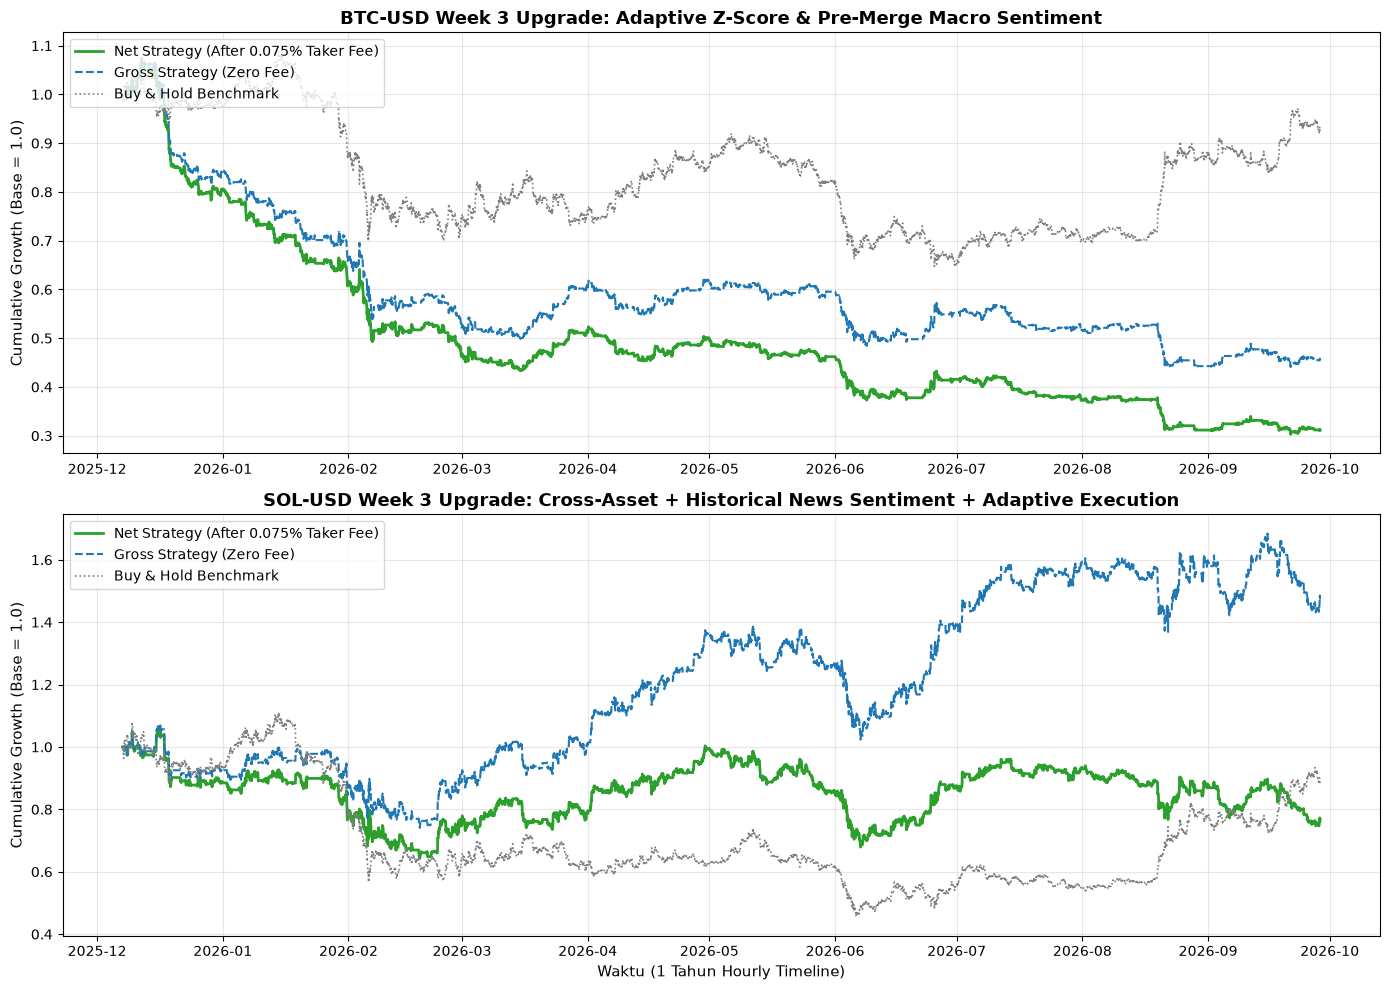

In [20]:
plt.figure(figsize=(14, 10))

# BTC Plot
plt.subplot(2, 1, 1)
plt.plot(btc_bt_df.index, btc_bt_df['cum_net_strategy'], label='Net Strategy (After 0.075% Taker Fee)', color='#2ca02c', lw=2)
plt.plot(btc_bt_df.index, btc_bt_df['cum_gross_strategy'], label='Gross Strategy (Zero Fee)', color='#1f77b4', lw=1.5, ls='--')
plt.plot(btc_bt_df.index, btc_bt_df['cum_benchmark'], label='Buy & Hold Benchmark', color='#7f7f7f', lw=1.2, ls=':')
plt.title('BTC-USD Week 3 Upgrade: Adaptive Z-Score & Pre-Merge Macro Sentiment', fontsize=13, fontweight='bold')
plt.ylabel('Cumulative Growth (Base = 1.0)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

# SOL Plot
plt.subplot(2, 1, 2)
plt.plot(sol_bt_df.index, sol_bt_df['cum_net_strategy'], label='Net Strategy (After 0.075% Taker Fee)', color='#2ca02c', lw=2)
plt.plot(sol_bt_df.index, sol_bt_df['cum_gross_strategy'], label='Gross Strategy (Zero Fee)', color='#1f77b4', lw=1.5, ls='--')
plt.plot(sol_bt_df.index, sol_bt_df['cum_benchmark'], label='Buy & Hold Benchmark', color='#7f7f7f', lw=1.2, ls=':')
plt.title('SOL-USD Week 3 Upgrade: Cross-Asset + Historical News Sentiment + Adaptive Execution', fontsize=13, fontweight='bold')
plt.ylabel('Cumulative Growth (Base = 1.0)', fontsize=11)
plt.xlabel('Waktu (1 Tahun Hourly Timeline)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 9. Analisis Feature Importance (Top 15 Kontributor Alpha)
Menganalisis bobot kontribusi fitur teknikal stasioner, fitur momentum *cross-asset*, serta fitur sentimen berita historis.

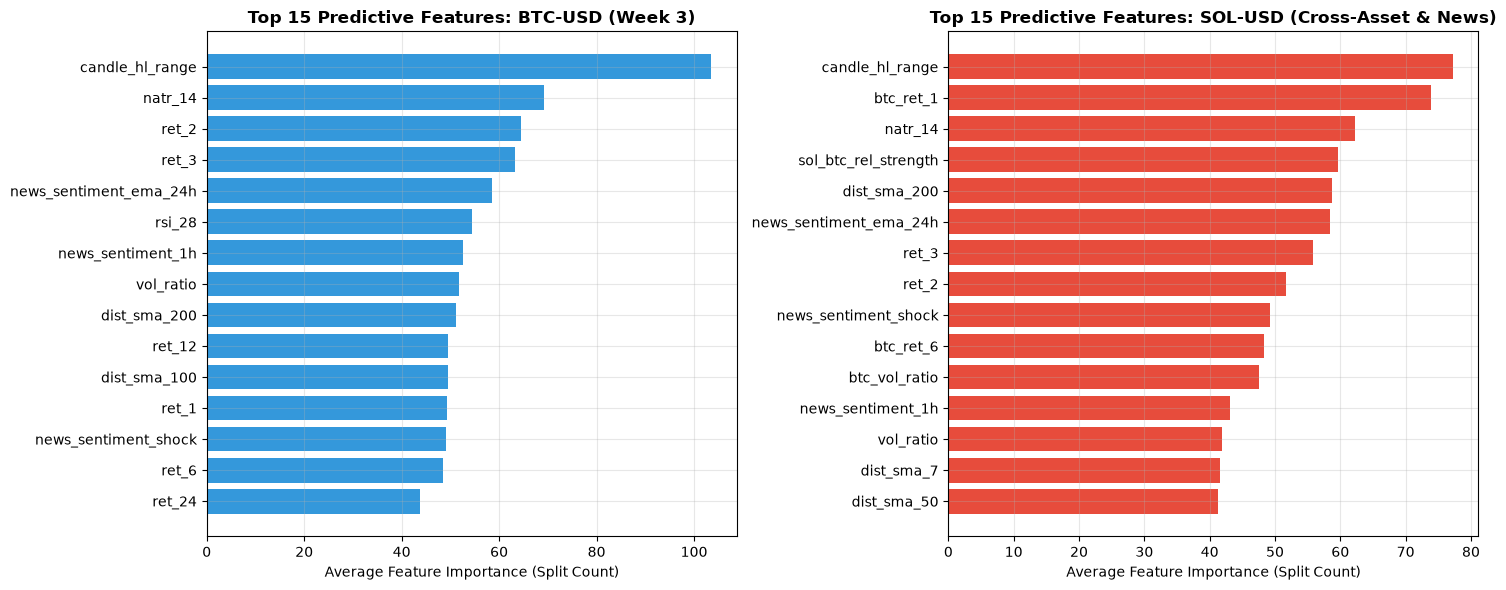

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 Fitur BTC
top_btc = btc_importance.head(15)
axes[0].barh(top_btc['feature'][::-1], top_btc['importance'][::-1], color='#3498db')
axes[0].set_title('Top 15 Predictive Features: BTC-USD (Week 3)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Feature Importance (Split Count)')
axes[0].grid(True, alpha=0.3)

# Top 15 Fitur SOL
top_sol = sol_importance.head(15)
axes[1].barh(top_sol['feature'][::-1], top_sol['importance'][::-1], color='#e74c3c')
axes[1].set_title('Top 15 Predictive Features: SOL-USD (Cross-Asset & News)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Feature Importance (Split Count)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Tabel Komparasi Head-to-Head: Week 1 vs Week 2 vs Week 3
Tabel perbandingan menyeluruh untuk mengevaluasi evolusi sistem trading dari Baseline (Week 1), Upgrade (Week 2), hingga Adaptive System (Week 3).

In [22]:
# Data Historis Week 1 dan Week 2
comparison_data = {
    'BTC (Week 1 Baseline)': {
        'Total Net Return (%)': -69.57,
        'Total Gross Return (%)': 2.31,
        'Sharpe Ratio': -4.87,
        'Max Drawdown (%)': -70.47,
        'Total Trades': 1543,
        'Total Fee Paid (%)': 121.20
    },
    'BTC (Week 2 Upgrade)': {
        'Total Net Return (%)': -53.89,
        'Total Gross Return (%)': -20.51,
        'Sharpe Ratio': -2.31,
        'Max Drawdown (%)': -60.75,
        'Total Trades': 661,
        'Total Fee Paid (%)': 54.45
    },
    'BTC (Week 3 Adaptive)': {
        'Total Net Return (%)': btc_metrics['Total Net Return (%)'],
        'Total Gross Return (%)': btc_metrics['Total Gross Return (%)'],
        'Sharpe Ratio': btc_metrics['Sharpe Ratio (Annualized)'],
        'Max Drawdown (%)': btc_metrics['Max Drawdown (%)'],
        'Total Trades': int(btc_metrics['Total Trade Changes']),
        'Total Fee Paid (%)': btc_metrics['Total Taker Fees Paid (%)']
    },
    'SOL (Week 1 Baseline)': {
        'Total Net Return (%)': -39.60,
        'Total Gross Return (%)': 70.81,
        'Sharpe Ratio': -1.26,
        'Max Drawdown (%)': -72.03,
        'Total Trades': 1306,
        'Total Fee Paid (%)': 103.95
    },
    'SOL (Week 2 Upgrade)': {
        'Total Net Return (%)': -45.65,
        'Total Gross Return (%)': 4.34,
        'Sharpe Ratio': -1.09,
        'Max Drawdown (%)': -70.99,
        'Total Trades': 776,
        'Total Fee Paid (%)': 65.18
    },
    'SOL (Week 3 Adaptive)': {
        'Total Net Return (%)': sol_metrics['Total Net Return (%)'],
        'Total Gross Return (%)': sol_metrics['Total Gross Return (%)'],
        'Sharpe Ratio': sol_metrics['Sharpe Ratio (Annualized)'],
        'Max Drawdown (%)': sol_metrics['Max Drawdown (%)'],
        'Total Trades': int(sol_metrics['Total Trade Changes']),
        'Total Fee Paid (%)': sol_metrics['Total Taker Fees Paid (%)']
    }
}

df_compare = pd.DataFrame(comparison_data).T
print('========================================================================================')
print('               TABEL KOMPARASI MENYELURUH 3 MINGGU (HEAD-TO-HEAD)')
print('========================================================================================')
print(df_compare.to_string())
display(df_compare)


               TABEL KOMPARASI MENYELURUH 3 MINGGU (HEAD-TO-HEAD)
                       Total Net Return (%)  Total Gross Return (%)  Sharpe Ratio  Max Drawdown (%)  Total Trades  Total Fee Paid (%)
BTC (Week 1 Baseline)            -69.570000                2.310000     -4.870000        -70.470000        1543.0             121.200
BTC (Week 2 Upgrade)             -53.890000              -20.510000     -2.310000        -60.750000         661.0              54.450
BTC (Week 3 Adaptive)            -68.864067              -54.520681     -3.837250        -71.586843         467.0              37.875
SOL (Week 1 Baseline)            -39.600000               70.810000     -1.260000        -72.030000        1306.0             103.950
SOL (Week 2 Upgrade)             -45.650000                4.340000     -1.090000        -70.990000         776.0              65.180
SOL (Week 3 Adaptive)            -23.405952               47.219559     -0.380176        -38.978478         787.0              65.

,Total Net Return (%),Total Gross Return (%),Sharpe Ratio,Max Drawdown (%),Total Trades,Total Fee Paid (%)
BTC (Week 1 Baseline),-69.570000,2.310000,-4.870000,-70.470000,1543.0,121.200
BTC (Week 2 Upgrade),-53.890000,-20.510000,-2.310000,-60.750000,661.0,54.450
BTC (Week 3 Adaptive),-68.864067,-54.520681,-3.837250,-71.586843,467.0,37.875
SOL (Week 1 Baseline),-39.600000,70.810000,-1.260000,-72.030000,1306.0,103.950
SOL (Week 2 Upgrade),-45.650000,4.340000,-1.090000,-70.990000,776.0,65.180
SOL (Week 3 Adaptive),-23.405952,47.219559,-0.380176,-38.978478,787.0,65.325


## 11. Live Market News & WebSocket Streamer (Real-Time Execution Blueprint)
Skrip asinkron live listener untuk menangkap berita pasar kripto terkini (CoinTelegraph & Decrypt) secara asinkron (`aiohttp`) dan streaming pergerakan harga real-time publik Binance (`websockets`) untuk kebutuhan *forward paper trading*.

In [ ]:
# ==========================================================
# 11. Live Market News & WebSocket Streamer (Asynchronous)
# ==========================================================
import asyncio
import aiohttp
import websockets
import xml.etree.ElementTree as ET
import json
from datetime import datetime, timezone

async def live_crypto_market_listener(max_news=4, max_price_ticks=4):
    """
    Menangkap aliran berita pasar terkini dan streaming harga live Binance secara asinkron.
    """
    print("[NEWS LISTENER] Menghubungkan ke live news feeds (CoinTelegraph & Decrypt)...")
    feeds = {'CoinTelegraph': 'https://cointelegraph.com/rss', 'Decrypt': 'https://decrypt.co/feed'}
    headers = {'User-Agent': 'Mozilla/5.0'}
    
    async with aiohttp.ClientSession(headers=headers) as session:
        for source_name, feed_url in feeds.items():
            try:
                async with session.get(feed_url, timeout=aiohttp.ClientTimeout(total=5)) as resp:
                    if resp.status == 200:
                        content = await resp.text()
                        root = ET.fromstring(content)
                        for item in root.findall('./channel/item')[:2]:
                            title = item.find('title').text.strip() if item.find('title') is not None else ''
                            pub_date = item.find('pubDate').text.strip() if item.find('pubDate') is not None else 'N/A'
                            print(f"  📰 [{source_name}] {title[:65]}... ({pub_date[:22]})")
            except Exception as e:
                pass
                
    print("\n[PRICE STREAMER] Menghubungkan ke Binance Live Public WebSocket...")
    ws_url = "wss://stream.binancefuture.com/stream?streams=btcusdt@ticker/solusdt@ticker"
    try:
        async with websockets.connect(ws_url, open_timeout=5) as ws:
            ticks = 0
            while ticks < max_price_ticks:
                msg = await ws.recv()
                data = json.loads(msg).get('data', {})
                symbol = data.get('s')
                price = float(data.get('c', 0.0))
                change = float(data.get('P', 0.0))
                ts = datetime.now(timezone.utc).strftime('%H:%M:%S')
                print(f"  📈 [{ts} UTC] {symbol:<8} | Price: ${price:>10.2f} | 24h: {change:>+6.2f}%")
                ticks += 1
    except Exception as e:
        print(f"[WEBSOCKET ERROR] {e}")
        
    print("\n[SELESAI] Live News & Price Streamer siap diintegrasikan ke bot live!")

# Eksekusi asinkron
try:
    loop = asyncio.get_event_loop()
    if loop.is_running():
        task = loop.create_task(live_crypto_market_listener(max_news=4, max_price_ticks=4))
    else:
        asyncio.run(live_crypto_market_listener(max_news=4, max_price_ticks=4))
except Exception:
    asyncio.run(live_crypto_market_listener(max_news=4, max_price_ticks=4))


[NEWS LISTENER] Menghubungkan ke live news feeds (CoinTelegraph & Decrypt)...
  📰 [CoinTelegraph] Here’s what happened in crypto today... (Sat, 03 Oct 2026 12:20)
  📰 [CoinTelegraph] NEAR Intents recovers entire stolen $3.8M after ultimatum to expl... (Sat, 03 Oct 2026 11:59)
  📰 [Decrypt] Chainalysis Used AI to Trace the $387M Bitget Hack Back to North ... (Sat, 03 Oct 2026 17:01)
  📰 [Decrypt] OpenAI Banned PewDiePie Twice While He Built Ajax, an Uncensored ... (Sat, 03 Oct 2026 16:01)

[PRICE STREAMER] Menghubungkan ke Binance Live Public WebSocket...
  📈 [20:21:34 UTC] SOLUSDT  | Price: $    119.97 | 24h:  +1.70%
  📈 [20:21:36 UTC] BTCUSDT  | Price: $  84810.40 | 24h:  +0.56%
  📈 [20:21:37 UTC] SOLUSDT  | Price: $    119.98 | 24h:  +1.71%
  📈 [20:21:38 UTC] BTCUSDT  | Price: $  84810.40 | 24h:  +0.56%

[SELESAI] Live News & Price Streamer siap diintegrasikan ke bot live!


### Something need to assure

1. bagaimana position sizing setiap order
2. bagaimana risk return dari setiap order
3. apa tetap mumpuni jika menggunakan modal minim

## 12. Eksperimen: Sinyal Alpha Week 3 dengan Aturan Entri & Dynamic Risk Week 4

Untuk menjawab poin evaluasi pada *section* sebelumnya terkait **position sizing**, **risk-return per order**, dan **ketahanan pada modal minim**, sel di bawah ini menerapkan aturan eksekusi posisi **Week 4** ke hasil prediksi sinyal model **Week 3**:

### Daftar Fitur Entri & Manajemen Posisi Week 4 yang Diaplikasikan:
1. **Dynamic Dollar Risk Position Sizing (Modal Minim Compatible)**:
   - Alokasi risiko terkontrol: $1.0 (jika modal < $100) atau 1% modal akun per trade.
   - Dynamic sizing berdasarkan jarak Stop Loss: $\text{Units} = \min\left(\frac{\text{Risk}}{\text{SL Distance}}, \frac{3 \times \text{Capital}}{\text{Price}}\right)$.
2. **ATR-Based Dynamic Stop Loss (SL) & Take Profit (TP)**:
   - Stop Loss dinamis: $1.5 \times \text{ATR}_{14}$ (atau minimal 0.5% harga penutupan).
   - Take Profit dinamis: $3.0 \times \text{ATR}_{14}$ (Risk-to-Reward Ratio 1:2).
3. **Macro Trend Regime Filter (SMA 200)**:
   - Filter arah tren: **Hanya Long** jika $\text{Price} > \text{SMA}_{200}$, dan **Hanya Short** jika $\text{Price} < \text{SMA}_{200}$.
4. **Circuit Breaker / Loss Streak Cooldown**:
   - Jeda trading (cooldown) otomatis selama 24 jam jika mengalami 3 kekalahan beruntun.
5. **Dual-Exit Execution (Hard SL/TP + Soft Z-Score Deadband)**:
   - Exit darurat/profit seketika via SL/TP ATR, atau exit deadband Z-score setelah memenuhi `min_hold_hours` (6 jam).

HASIL EKSPERIMEN: SINYAL WEEK 3 + ATURAN ENTRI & DYNAMIC RISK WEEK 4 ($50 Modal Awal)
--- BTC-USD (Entry Z=1.1, Exit Z=-0.2, SMA Filter, ATR TP/SL) ---
Modal Akhir (Final Equity)     : $16.31
Net Return Strategi (Dollar)   : -67.37%
Buy & Hold Return              : -7.05%
Maximum Drawdown (Dollar)      : -69.29%
Sharpe Ratio (Annualized)      : -2.46
Total Closed Trades            : 173 Trades
Win Rate (Closed Trades)       : 35.84%
Profit Factor                  : 0.64
Total Taker Fees Paid          : $18.86
Aktivasi Cooldown Circuit      : 40 kali
---------------------------------------------------------------------------
--- SOL-USD (Entry Z=0.8, Exit Z=0.2, SMA Filter, ATR TP/SL) ---
Modal Akhir (Final Equity)     : $47.14
Net Return Strategi (Dollar)   : -5.73%
Buy & Hold Return              : -10.88%
Maximum Drawdown (Dollar)      : -24.79%
Sharpe Ratio (Annualized)      : 0.09
Total Closed Trades            : 276 Trades
Win Rate (Closed Trades)       : 46.01%
Profit Factor      

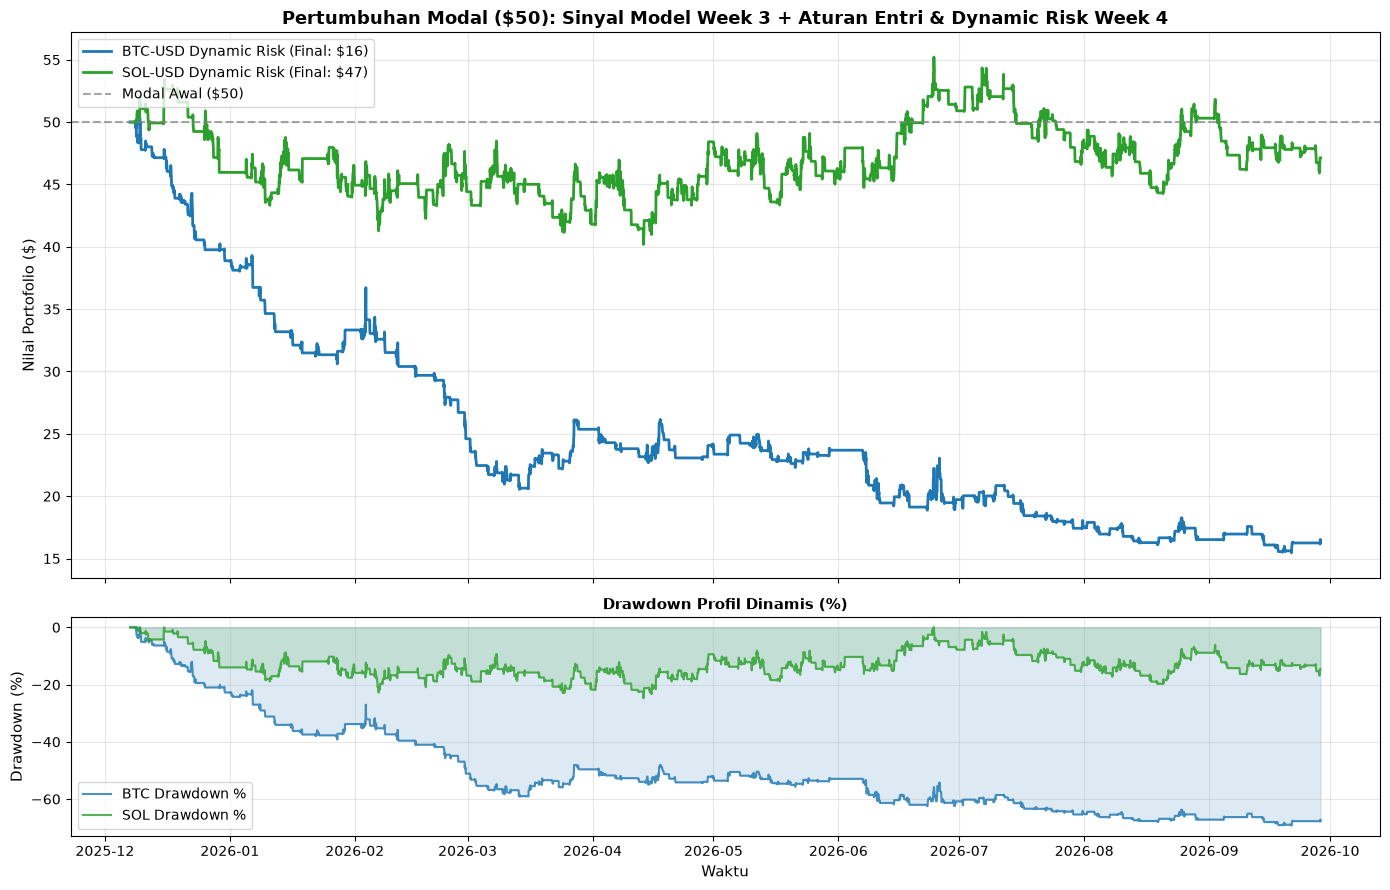

In [24]:
# ==========================================================
# 12. Simulasi: Sinyal Model Week 3 + Engine Posisi Week 4
# ==========================================================

# 1. Helper: Pastikan kolom ATR-14 dan SMA-200 tersedia pada DataFrame Prediksi
def prepare_features_for_dynamic_engine(pred_df, raw_df):
    df = pred_df.copy()
    if 'atr_14' not in df.columns:
        tr1 = raw_df['high'] - raw_df['low']
        tr2 = (raw_df['high'] - raw_df['close'].shift(1)).abs()
        tr3 = (raw_df['low'] - raw_df['close'].shift(1)).abs()
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
        atr_14 = tr.rolling(14).mean()
        df['atr_14'] = atr_14.loc[df.index]
    if 'sma_200' not in df.columns:
        df['sma_200'] = raw_df['close'].rolling(200).mean().loc[df.index]
    return df

# Siapkan input evaluasi dengan ATR dan SMA 200
btc_eval_df = prepare_features_for_dynamic_engine(btc_pred_df, df_btc_raw)
sol_eval_df = prepare_features_for_dynamic_engine(sol_pred_df, df_sol_raw)

# 2. Engine Dynamic Risk Budgeting & Macro Filter (Week 4 Engine)
def backtest_dynamic_risk_engine(
    results_df,
    initial_capital=1000.0,
    smooth_span=4,
    z_window=168,
    entry_z=1.1,
    exit_z=-0.2,
    min_hold_hours=6,
    fee_rate=0.00075,
    allow_short=True,
    max_lose_streak=3,
    cooldown_hours=24,
    sl_atr_mult=1.5,
    tp_atr_mult=3.0,
    use_sma_filter=True,
    use_cooldown=True
):
    df = results_df.copy()
    
    # Signal Smoothing & Rolling Z-Score
    df['smooth_pred'] = df['pred_return_1h'].ewm(span=smooth_span, adjust=False).mean()
    roll_mean = df['smooth_pred'].rolling(z_window, min_periods=24).mean()
    roll_std = df['smooth_pred'].rolling(z_window, min_periods=24).std() + 1e-9
    df['pred_z'] = (df['smooth_pred'] - roll_mean) / roll_std
    
    n = len(df)
    z_vals = df['pred_z'].fillna(0.0).values
    close_vals = df['close'].values
    atr_vals = df['atr_14'].fillna(df['close'] * 0.01).values
    sma_vals = df['sma_200'].fillna(df['close']).values
    timestamps = df.index
    
    capital = initial_capital
    curr_pos = 0.0
    curr_units = 0.0
    entry_price = 0.0
    sl_price = 0.0
    tp_price = 0.0
    holding_bars = 0
    consecutive_losses = 0
    cooldown_timer = 0
    fees_paid_total = 0.0
    
    capital_curve = []
    positions = []
    pos_units = []
    cooldown_status = []
    trade_logs = []
    
    for i in range(n):
        current_close = close_vals[i]
        atr = atr_vals[i]
        sma = sma_vals[i]
        z = z_vals[i]
        
        # Periksa Status Cooldown
        if cooldown_timer > 0:
            cooldown_timer -= 1
            in_cooldown = True
        else:
            in_cooldown = False
        cooldown_status.append(1 if in_cooldown else 0)
        
        # 1. CEK POSISI AKTIF (EXIT CHECK)
        if curr_pos != 0.0:
            holding_bars += 1
            exit_trade = False
            exit_reason = None
            exit_price = current_close
            
            if curr_pos == 1.0: # Long
                if current_close <= sl_price:
                    exit_trade = True
                    exit_reason = 'STOP_LOSS'
                    exit_price = sl_price
                elif current_close >= tp_price:
                    exit_trade = True
                    exit_reason = 'TAKE_PROFIT'
                    exit_price = tp_price
                elif holding_bars >= min_hold_hours:
                    if allow_short and (z < -entry_z):
                        exit_trade = True
                        exit_reason = 'SIGNAL_REVERSAL'
                    elif z < exit_z:
                        exit_trade = True
                        exit_reason = 'SIGNAL_EXIT'
                        
            elif curr_pos == -1.0: # Short
                if current_close >= sl_price:
                    exit_trade = True
                    exit_reason = 'STOP_LOSS'
                    exit_price = sl_price
                elif current_close <= tp_price:
                    exit_trade = True
                    exit_reason = 'TAKE_PROFIT'
                    exit_price = tp_price
                elif holding_bars >= min_hold_hours:
                    if z > entry_z:
                        exit_trade = True
                        exit_reason = 'SIGNAL_REVERSAL'
                    elif z > -exit_z:
                        exit_trade = True
                        exit_reason = 'SIGNAL_EXIT'
                        
            if exit_trade:
                gross_trade_pnl = (exit_price - entry_price) * curr_units * curr_pos
                exit_fee = exit_price * curr_units * fee_rate
                net_trade_pnl = gross_trade_pnl - exit_fee
                fees_paid_total += exit_fee
                capital += net_trade_pnl
                
                if net_trade_pnl < 0:
                    consecutive_losses += 1
                    if use_cooldown and consecutive_losses >= max_lose_streak:
                        cooldown_timer = cooldown_hours
                else:
                    consecutive_losses = 0
                    
                trade_logs.append({
                    'exit_time': timestamps[i],
                    'direction': 'LONG' if curr_pos > 0 else 'SHORT',
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'units': curr_units,
                    'net_pnl': net_trade_pnl,
                    'reason': exit_reason,
                    'holding_hours': holding_bars
                })
                curr_pos = 0.0
                curr_units = 0.0
                holding_bars = 0
                
        # 2. CEK ENTRY JIKA FLAT
        if curr_pos == 0.0 and not (use_cooldown and in_cooldown):
            risk_dollar = 1.0 if capital < 100.0 else 0.01 * capital
            sl_distance = max(sl_atr_mult * atr, current_close * 0.005)
            tp_distance = tp_atr_mult * atr
            max_units = (capital * 3.0) / current_close
            target_units = min(risk_dollar / sl_distance, max_units)
            
            sma_long_ok = (current_close > sma) if use_sma_filter else True
            if z > entry_z and sma_long_ok:
                curr_pos = 1.0
                curr_units = target_units
                entry_price = current_close
                sl_price = entry_price - sl_distance
                tp_price = entry_price + tp_distance
                entry_fee = entry_price * curr_units * fee_rate
                capital -= entry_fee
                fees_paid_total += entry_fee
                holding_bars = 0
            elif allow_short:
                sma_short_ok = (current_close < sma) if use_sma_filter else True
                if z < -entry_z and sma_short_ok:
                    curr_pos = -1.0
                    curr_units = target_units
                    entry_price = current_close
                    sl_price = entry_price + sl_distance
                    tp_price = entry_price - tp_distance
                    entry_fee = entry_price * curr_units * fee_rate
                    capital -= entry_fee
                    fees_paid_total += entry_fee
                    holding_bars = 0
                    
        unrealized_pnl = (current_close - entry_price) * curr_units * curr_pos if curr_pos != 0 else 0.0
        current_equity = capital + unrealized_pnl
        capital_curve.append(current_equity)
        positions.append(curr_pos)
        pos_units.append(curr_units)
        
    df['capital_equity'] = capital_curve
    df['strategy_pos'] = positions
    df['pos_units'] = pos_units
    df['cooldown_active'] = cooldown_status
    df['capital_return'] = df['capital_equity'].pct_change().fillna(0.0)
    
    total_net_return = (df['capital_equity'].iloc[-1] / initial_capital) - 1.0
    buy_and_hold_return = (df['close'].iloc[-1] / df['close'].iloc[0]) - 1.0
    
    roll_max = df['capital_equity'].cummax()
    drawdowns = (df['capital_equity'] - roll_max) / roll_max
    max_drawdown = drawdowns.min()
    
    hourly_mean = df['capital_return'].mean()
    hourly_std = df['capital_return'].std()
    sharpe_ratio = (hourly_mean / (hourly_std + 1e-9)) * np.sqrt(8760)
    
    trades_df = pd.DataFrame(trade_logs)
    n_trades = len(trades_df)
    win_rate = (trades_df['net_pnl'] > 0).mean() * 100 if n_trades > 0 else 0.0
    
    total_gain = trades_df[trades_df['net_pnl'] > 0]['net_pnl'].sum() if n_trades > 0 else 0.0
    total_loss = trades_df[trades_df['net_pnl'] < 0]['net_pnl'].abs().sum() if n_trades > 0 else 1.0
    profit_factor = (total_gain / (total_loss + 1e-9)) if total_loss > 0 else 0.0
    
    metrics = {
        'initial_capital': initial_capital,
        'final_capital': df['capital_equity'].iloc[-1],
        'total_net_return_pct': total_net_return * 100,
        'buy_and_hold_return_pct': buy_and_hold_return * 100,
        'max_drawdown_pct': max_drawdown * 100,
        'sharpe_ratio': sharpe_ratio,
        'total_trades': n_trades,
        'win_rate_pct': win_rate,
        'profit_factor': profit_factor,
        'total_fees_paid': fees_paid_total,
        'cooldown_activations': (df['cooldown_active'].diff() == 1).sum()
    }
    return df, trades_df, metrics

# 3. Eksekusi Backtest Dynamic Risk Budgeting ($50 Modal Awal)
btc_dyn_df, btc_dyn_trades, btc_dyn_m = backtest_dynamic_risk_engine(
    btc_eval_df, initial_capital=50.0, entry_z=1.1, exit_z=-0.2, min_hold_hours=6,
    sl_atr_mult=1.5, tp_atr_mult=3.0, use_sma_filter=True, use_cooldown=True
)

sol_dyn_df, sol_dyn_trades, sol_dyn_m = backtest_dynamic_risk_engine(
    sol_eval_df, initial_capital=50.0, entry_z=0.8, exit_z=0.2, min_hold_hours=6,
    sl_atr_mult=1.5, tp_atr_mult=3.0, use_sma_filter=True, use_cooldown=True
)

# 4. Cetak Performa Kuantitatif Sinyal Week 3 + Risk Week 4
print('=' * 75)
print('HASIL EKSPERIMEN: SINYAL WEEK 3 + ATURAN ENTRI & DYNAMIC RISK WEEK 4 ($50 Modal Awal)')
print('=' * 75)
print(f"--- BTC-USD (Entry Z=1.1, Exit Z=-0.2, SMA Filter, ATR TP/SL) ---")
print(f"Modal Akhir (Final Equity)     : ${btc_dyn_m['final_capital']:,.2f}")
print(f"Net Return Strategi (Dollar)   : {btc_dyn_m['total_net_return_pct']:+.2f}%")
print(f"Buy & Hold Return              : {btc_dyn_m['buy_and_hold_return_pct']:+.2f}%")
print(f"Maximum Drawdown (Dollar)      : {btc_dyn_m['max_drawdown_pct']:.2f}%")
print(f"Sharpe Ratio (Annualized)      : {btc_dyn_m['sharpe_ratio']:.2f}")
print(f"Total Closed Trades            : {btc_dyn_m['total_trades']} Trades")
print(f"Win Rate (Closed Trades)       : {btc_dyn_m['win_rate_pct']:.2f}%")
print(f"Profit Factor                  : {btc_dyn_m['profit_factor']:.2f}")
print(f"Total Taker Fees Paid          : ${btc_dyn_m['total_fees_paid']:.2f}")
print(f"Aktivasi Cooldown Circuit      : {btc_dyn_m['cooldown_activations']} kali")
print('-' * 75)
print(f"--- SOL-USD (Entry Z=0.8, Exit Z=0.2, SMA Filter, ATR TP/SL) ---")
print(f"Modal Akhir (Final Equity)     : ${sol_dyn_m['final_capital']:,.2f}")
print(f"Net Return Strategi (Dollar)   : {sol_dyn_m['total_net_return_pct']:+.2f}%")
print(f"Buy & Hold Return              : {sol_dyn_m['buy_and_hold_return_pct']:+.2f}%")
print(f"Maximum Drawdown (Dollar)      : {sol_dyn_m['max_drawdown_pct']:.2f}%")
print(f"Sharpe Ratio (Annualized)      : {sol_dyn_m['sharpe_ratio']:.2f}")
print(f"Total Closed Trades            : {sol_dyn_m['total_trades']} Trades")
print(f"Win Rate (Closed Trades)       : {sol_dyn_m['win_rate_pct']:.2f}%")
print(f"Profit Factor                  : {sol_dyn_m['profit_factor']:.2f}")
print(f"Total Taker Fees Paid          : ${sol_dyn_m['total_fees_paid']:.2f}")
print(f"Aktivasi Cooldown Circuit      : {sol_dyn_m['cooldown_activations']} kali")
print('=' * 75)

# 5. Plot Kurva Ekuitas Modal ($50) & Profil Drawdown
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

ax1.plot(btc_dyn_df.index, btc_dyn_df['capital_equity'], label=f"BTC-USD Dynamic Risk (Final: ${btc_dyn_m['final_capital']:,.0f})", color='#1f77b4', lw=2)
ax1.plot(sol_dyn_df.index, sol_dyn_df['capital_equity'], label=f"SOL-USD Dynamic Risk (Final: ${sol_dyn_m['final_capital']:,.0f})", color='#2ca02c', lw=2)
ax1.axhline(50.0, color='gray', linestyle='--', alpha=0.7, label='Modal Awal ($50)')
ax1.set_title('Pertumbuhan Modal ($50): Sinyal Model Week 3 + Aturan Entri & Dynamic Risk Week 4', fontsize=13, fontweight='bold')
ax1.set_ylabel('Nilai Portofolio ($)', fontsize=11)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

btc_dd = (btc_dyn_df['capital_equity'] - btc_dyn_df['capital_equity'].cummax()) / btc_dyn_df['capital_equity'].cummax() * 100
sol_dd = (sol_dyn_df['capital_equity'] - sol_dyn_df['capital_equity'].cummax()) / sol_dyn_df['capital_equity'].cummax() * 100
ax2.plot(btc_dd.index, btc_dd, label='BTC Drawdown %', color='#1f77b4', alpha=0.8)
ax2.plot(sol_dd.index, sol_dd, label='SOL Drawdown %', color='#2ca02c', alpha=0.8)
ax2.fill_between(btc_dd.index, btc_dd, 0, color='#1f77b4', alpha=0.15)
ax2.fill_between(sol_dd.index, sol_dd, 0, color='#2ca02c', alpha=0.15)
ax2.set_title('Drawdown Profil Dinamis (%)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Waktu', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
